# Coadding KCWI frames using Montage
Based on montage (http://montage.ipac.caltech.edu/docs/) and the code from kcwitools: https://github.com/pypeit/kcwitools/blob/master/kcwitools/montage.py  
  
Citation for kcwitools: https://zenodo.org/records/6079396



In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import cwitools.scripts as cs
from MontagePy.main import *
from MontagePy.archive import *
from astropy.wcs import WCS

## Montage Function

In [2]:
import numpy as np

from astropy.io import fits
from astropy import units
from astropy.table import Table

#from kcwitools import image as im
from cwitools.scripts import cwi_crop 
import subprocess
import os

def run_montage(infils, # list of files
                outdir='Montage/',
                outfil="Montage.fits",
                northup=False,
                trimBL=False,trimBM=False, trimBS=False,
                grating='BL',
                clean=False,
                wl=3500,wh=5500, 
                xc1=2, xc2=28, 
                yc1=15, yc2=80):
    """ take a list of KCWI cubes and run montage on them
    Args:
    ----------
    infils: list
      list of kcwi cubes to montage
    outfil: string
      name of montage output file, defaults to Montage.fits'

    
    """
    
    #in case the user forgets the trailing /
    outdir = outdir+'/'

    #outfile = 'mosaic_cube.fits'
    if os.path.exists(outdir+outfil):
        os.remove(outdir+outfil)  # Delete the old file
        os.remove(outdir+outfil[:-5]+"_area.fits")
 
    #create the driectories
    subprocess.Popen(["mkdir",outdir])
    subprocess.Popen(["mkdir",outdir+"Input"])
    subprocess.Popen(["mkdir",outdir+"Projection"])

    #copy
    for fil in infils:
        #check to see if you are trimming, and a BM slicer
        if(trimBM):
            trim_medium_premontage(fil,wl,wh)
            a, b = fil.split(".fits")
            trim = a + '.c.fits'
            subprocess.Popen(["cp",trim,outdir+"Input"]).wait()
        elif(trimBL):
            trim_large_premontage(fil,wl,wh, xc1, xc2, yc1, yc2)
            a, b = fil.split(".fits")
            trim = a + '.c.fits'
            #fix_kcwi_cube_montage_BL(trim)
            subprocess.Popen(["cp",trim,outdir+"Input"]).wait()
        elif(trimBS):
            trim_small_premontage(fil, wl, wh)
            a, b = fil.split(".fits")
            trim = a + '.c.fits'
            fix_kcwi_cube_montage_BM(trim)
            subprocess.Popen(["cp",trim,outdir+"Input"]).wait()

        else:
            subprocess.Popen(["cp",fil,outdir+"Input"]).wait()


    inputs = []
    for root, dirs,files in os.walk(outdir+'Input/'):
        for file in files:
            inputs.append(file)
    

    
    #first part of montage
    subprocess.Popen(["mImgtbl","-c",outdir+"Input/",outdir+"cubes.tbl"]).wait()
    subprocess.Popen(["mMakeHdr",outdir+"cubes.tbl",outdir+"cubes.hdr"]).wait()

    ##are you forcing pixels to be north up?
    if northup:
        tab=Table.read(outdir+'cubes.hdr',format='ascii',data_end=19)
        tab[17][2]='0.000000000'
        tab.add_row(['END',' ',' '])
        tab.write(outdir+'cubes.hdr',format='ascii',overwrite=True)
        
    #second part of montage
    for fil in inputs:
        tmp=fil.split(".")
        subprocess.Popen(["mProjectCube",outdir+"Input/"+fil,outdir+"Projection/"+tmp[0]+"_proj.fits",outdir+"cubes.hdr"]).wait()

    #final part of montage
    subprocess.Popen(["mImgtbl","-c",outdir+"Projection/",outdir+"cubes-proj.tbl"]).wait()
    subprocess.Popen(["mAddCube","-p",outdir+"Projection/",outdir+"cubes-proj.tbl",outdir+"cubes.hdr",outdir+outfil]).wait()

    #remove all montage created bits aside from output file (default is off)
    if(clean):
        subprocess.Popen(["rm","-rf",outdir+"Input"])
        subprocess.Popen(["rm","-rf",outdir+"Projection"])
        subprocess.Popen(["rm",outdir+"cubes.tbl",outdir+"cubes.hdr",outdir+"cubes-proj.tbl"])
        subprocess.Popen(["rm",outdir+"*.c.fits"])
        subprocess.Popen(["rm",outdir+"*.area.fits"])
        subprocess.Popen(["rm",outdir+"*_area.fits"])
        

    # Calculate the total exposure time
    tt0 = 0
    tot_exp = 0.0
    for i in infils:
        fi = fits.open(i)[0]
        tot_exp = tot_exp +  fi.header["TTIME"]
        #print("Frame #"+str(tt0)+" EXPTIME: "+str(fi.header["TTIME"])+"s")
        tt0 = tt0 + 1
        tot_exp = int(tot_exp)

    #fix the header after montage is done
    hdr_k = fits.open(infils[0])[0].header
    fix_kcwi_cube_montage(outdir+outfil, hdr_k, tot_exp)
    #if (grating == 'BL')|(grating == 'RL'):
    #    fix_kcwi_cube_montage_BL(outdir+outfil)
    #if grating == 'BM':
    #    fix_kcwi_cube_montage_BM(outdir+outfil)
        

###Add the CD3_3 and CDELT3 keywords to a BL grating cube
def fix_kcwi_cube_montage(mosaicfil, hdr_k, total_exposure_time):
    # hdr_k: is the header of the first icubes.fits file in the infils list
    hdu = fits.open(mosaicfil)
    flux = hdu['PRIMARY'].data
    hdu_hdr = hdu['PRIMARY'].header
    # adding keywords for spatial grid
    CDELT1 = hdu_hdr["CDELT1"]
    CDELT2 = hdu_hdr["CDELT2"]
    theta  = np.deg2rad(hdu_hdr.get("CROTA2", 0.0))
    
    CD11 = CDELT1 * np.cos(theta)
    CD12 = -CDELT2 * np.sin(theta)
    CD21 = CDELT1 * np.sin(theta)
    CD22 = CDELT2 * np.cos(theta)
    
    # Write CD matrix
    hdu_hdr["CD1_1"] = CD11
    hdu_hdr["CD1_2"] = CD12
    hdu_hdr["CD2_1"] = CD21
    hdu_hdr["CD2_2"] = CD22
    
    # updating the wavelength keywords
    crval3 = hdu_hdr['CRVAL3']
    crpix3 = hdu_hdr['CRPIX3']

    
    #Make it so that there is no offset (shift zeropint and zero the offset)
    hdu_hdr['CRVAL3'] = crval3 - crpix3
    hdu_hdr['CRPIX3'] = 0.0
    hdu_hdr['CDELT3'] = hdr_k['CD3_3']
    keywords = ['CD3_3', 'BINNING', 'IFUNAM', 'BGRATNAM', 'WAVALL0', 'WAVALL1', 'WAVGOOD0', 'WAVGOOD1', 'WAVMID', 'PROGNAME', 'BUNIT']#hdrf['BUNIT']
    
    for key in keywords:
        if key in hdr_k:
            value = hdr_k[key]
            comment = hdr_k.comments[key]  # preserve the comment too
            hdu_hdr[key] = (value, comment)
            
    hdu_hdr['TTIME'] = (total_exposure_time, 'TOTAL EXPOSURE TIMES (SECONDS)')

    hdu_out = fits.PrimaryHDU(flux, header=hdu_hdr)
    hdu_out.writeto(mosaicfil, overwrite=True)


###Trim the large slicer for montage
def trim_large_premontage(infil, wc1, wc2, xc1=2, xc2=25, yc1=14, yc2=79):
    #subprocess.Popen(["cwi_crop","-cube",infil,"-wcrop",str(wl), str(wh),"-ycrop","17 81","-xcrop","3 26"]).wait()
    cwi_crop(infil,xcrop=(xc1,xc2),ycrop=(yc1,yc2),wcrop=(wc1,wc2))
    
###Trim the medium slicer for montage
def trim_medium_premontage(infil,wl,wh):
    subprocess.Popen(["cwi_crop","-cube",infil,"-wcrop",str(wl), str(wh),"-ycrop","17 81","-xcrop","6 29"]).wait()

from cwitools.scripts import cwi_crop     
###Trim the small slicer for montage
def trim_small_premontage(infil, wc1, wc2, xc1=7, xc2=33, yc1=21, yc2=160):
    cwi_crop(infil,xcrop=(xc1,xc2),ycrop=(yc1,yc2),wcrop=(wc1,wc2))

In [3]:

!pwd

/home/ahmed/kcwi_reduction/redux


In [4]:
!ls ../*Med**.txt

../arcs2x2MedKBlueBLFeAr4500_10.0_5dea.txt
../arcs2x2MedKBlueBLThAr4500_20.0_5dea.txt
../cbars2x2MedKBlueBL_4500_0.7_5dea.txt
../cflat2x2MedKBlueBL_4500_0.7_5dea.txt
../dflat2x2MedKBlueBL_4500_14.0_5dea.txt
../g191b2b2x2MedKBlueBL4500_5dea.txt
../J045313-1305552x2MedKBlueBL4500_5dea.txt


In [6]:
!cat ../J045313-1305552x2MedKBlueBL4500_5dea.txt

kb180215_00075.fits
kb180215_00076.fits
kb180215_00077.fits
kb180215_00078.fits
kb180215_00079.fits
kb180215_00080.fits


In [7]:
!ls *icubes*

kb180215_00068_icubes.fits  kb180215_00077_icubes.fits
kb180215_00069_icubes.fits  kb180215_00078_icubes.fits
kb180215_00070_icubes.fits  kb180215_00079_icubes.fits
kb180215_00075_icubes.fits  kb180215_00080_icubes.fits
kb180215_00076_icubes.fits


In [10]:
infils = ['kb180215_000'+str(i)+'_icubes.fits' for i in range(75, 81)]
infils

['kb180215_00075_icubes.fits',
 'kb180215_00076_icubes.fits',
 'kb180215_00077_icubes.fits',
 'kb180215_00078_icubes.fits',
 'kb180215_00079_icubes.fits',
 'kb180215_00080_icubes.fits']

## Extract the variance from the `*icubes_fits` files for the science frames

In [11]:
infils = ['kb180215_000'+str(i)+'_icubes.fits' for i in range(75, 81)]

save = 1#1

for i in range(len(infils)):
    infil = infils[i]
    f_name = infils[i][:15]
    hdu = fits.open(infil)
    
    var_un = hdu[2].data**2.
    hdr_var = hdu[0].header
    hdr_var["EXTNAME"] = "VARIANCE"
    hdr_var["BUNIT"] = "VARIANCE_UNITS"
    
    primary_hdu_var = fits.PrimaryHDU(var_un, hdr_var)
    hdu_var = fits.HDUList([primary_hdu_var])
    
    if save == True:
        hdu_var.writeto(f_name+'vcubes.fits', overwrite=True)
        print("==== SAVED The Variance File: "+f_name+'vcubes.fits   =====')
    #print(hdu.info())

==== SAVED The Variance File: kb180215_00075_vcubes.fits   =====
==== SAVED The Variance File: kb180215_00076_vcubes.fits   =====
==== SAVED The Variance File: kb180215_00077_vcubes.fits   =====
==== SAVED The Variance File: kb180215_00078_vcubes.fits   =====
==== SAVED The Variance File: kb180215_00079_vcubes.fits   =====
==== SAVED The Variance File: kb180215_00080_vcubes.fits   =====


In [12]:
!cat ../J045313-1305552x2MedKBlueBL4500_5dea.txt

kb180215_00075.fits
kb180215_00076.fits
kb180215_00077.fits
kb180215_00078.fits
kb180215_00079.fits
kb180215_00080.fits


## Check the cube spatial boundaries to get rid of the extra padding resulting from the pipeline

In [13]:
f = fits.open('kb180215_00075_icubes.fits')
f.info()

hdrf = f[0].header
df0 = f[0].data
wlf0 = np.nansum(df0[500:-500,:,:], axis=0)

print(wlf0.shape)
#wlf0
hdrf["BGRATNAM"], hdrf["IFUNAM"]

Filename: kb180215_00075_icubes.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     558   (34, 95, 2596)   float32   
  1  MASK          1 ImageHDU         9   (34, 95, 2596)   uint8   
  2  UNCERT        1 ImageHDU        10   (34, 95, 2596)   float32   
  3  FLAGS         1 ImageHDU         9   (34, 95, 2596)   uint8   
  4  NOSKYSUB      1 ImageHDU         9   (34, 95, 2596)   float32   
(95, 34)


('BL', 'Medium')

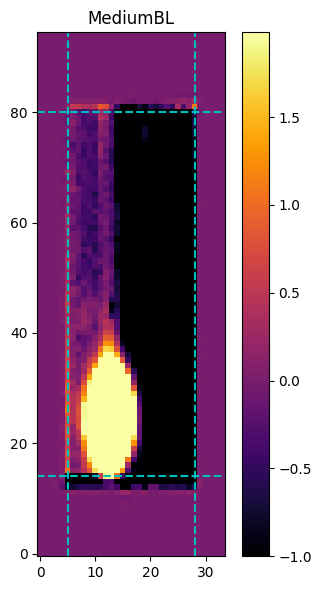

In [15]:


%matplotlib inline
#%matplotlib qt
plt.close()
fig = plt.figure(1, figsize=(4,6))
ax1 = fig.add_subplot(111)#, projection=wcs)#WCS(hdrf).celestial)
im1 = ax1.imshow(wlf0, origin='lower', interpolation='nearest', cmap='inferno', vmin=-1, vmax=0.003*wlf0.max())
#ax1.grid()
ax1.axvline(x=5, ls='--', c='c')
ax1.axvline(x=28, ls='--', c='c')
ax1.axhline(y=14, ls='--', c='c')
ax1.axhline(y=80, ls='--', c='c')
ax1.set_title(hdrf["IFUNAM"] + hdrf["BGRATNAM"] )
#Large BL: x0=2, xf=25, y0=16, yf=80
#Medium BL: x0=5, xf=28, y0=16, yf=80
fig.colorbar(im1)
fig.tight_layout()
plt.show()

#WCS(f[0].header), hdrf["CD1_1"] * 3600., hdrf["CD2_2"] * 3600., hdrf

## Medium-BL Setup

In [16]:
ls ../*Med**BL**.txt

../arcs2x2MedKBlueBLFeAr4500_10.0_5dea.txt
../arcs2x2MedKBlueBLThAr4500_20.0_5dea.txt
../cbars2x2MedKBlueBL_4500_0.7_5dea.txt
../cflat2x2MedKBlueBL_4500_0.7_5dea.txt
../dflat2x2MedKBlueBL_4500_14.0_5dea.txt
../g191b2b2x2MedKBlueBL4500_5dea.txt
../J045313-1305552x2MedKBlueBL4500_5dea.txt


In [17]:
!pwd

/home/ahmed/kcwi_reduction/redux


## J045313-130555

In [18]:
!cat ../J045313-1305552x2MedKBlueBL4500_5dea.txt

kb180215_00075.fits
kb180215_00076.fits
kb180215_00077.fits
kb180215_00078.fits
kb180215_00079.fits
kb180215_00080.fits


### Run Montage for this system

In [19]:
obs_date = "2018_02_15"
kcwi_setup = "Med_BL"
target_name = "J045313m130555"
montage_dir = '/home/ahmed/kcwi_reduction/'+target_name


with open('../J045313-1305552x2MedKBlueBL4500_5dea.txt', 'r') as file:
    lines = [line.strip() for line in file if line.strip() and line.strip().endswith('.fits')]
    base_names = [line.replace('.fits', '') for line in lines]
    infils = [name + '_icubes.fits' for name in base_names]
    infilsv = [name + '_vcubes.fits' for name in base_names]




hdr = fits.open(infils[0])[0].header
keys = ["WAVALL0", "WAVALL1", "WAVGOOD0", "WAVGOOD1", "WAVMID"]
wavelength_info = {k: (hdr[k], hdr.comments[k]) for k in keys}


tot_exp = 0.0
tt0 = 1
for i in infils:
    fi = fits.open(i)[0]
    tot_exp = tot_exp +  fi.header["TTIME"]
    print("Frame #"+str(tt0)+" EXPTIME: "+str(fi.header["TTIME"])+"s")
    tt0 = tt0 + 1
tot_exp = int(tot_exp)
print("Total Exposure Time: "+str(tot_exp)+"s")



wl, wh = wavelength_info['WAVALL0'][0], wavelength_info['WAVALL1'][0]#3226.6160962267786, 5821.968743889169


#Medium BL: x0=5, xf=28, y0=16, yf=80

### icubes files ####
# icubes_flux
# icubes_flux
run_montage(infils=infils, outdir=montage_dir,outfil=target_name+"_"+obs_date+"_"+kcwi_setup+"_"+str(tot_exp)+"s_icubes_flux.fits",
            northup=False, trimBL=True,clean=True,
            wl=wl,wh=wh, xc1=5, xc2=28, yc1=14, yc2=80)
# icubes_variance
run_montage(infils=infilsv, outdir=montage_dir,outfil=target_name+"_"+obs_date+"_"+kcwi_setup+"_"+str(tot_exp)+"s_icubes_var.fits",
            northup=False, trimBL=True,clean=True,
            wl=wl,wh=wh, xc1=5, xc2=28, yc1=14, yc2=80)

Frame #1 EXPTIME: 1200.0s
Frame #2 EXPTIME: 1200.0s
Frame #3 EXPTIME: 1200.0s
Frame #4 EXPTIME: 1200.0s
Frame #5 EXPTIME: 1200.0s
Frame #6 EXPTIME: 1200.0s
Total Exposure Time: 7200s

	2025-11-18 13:46:19.630792
	CROP:
		clist = kb180215_00075_icubes.fits
		ctype = None
		wcrop = (3226.819661518035, 5822.76191379245)
		xcrop = (5, 28)
		ycrop = (14, 80)
		plot = None
		ext = .c.fits
		outdir = None
		log = None
		silent = None
	Saved kb180215_00075_icubes.c.fits


	2025-11-18 13:46:19.764402
	CROP:
		clist = kb180215_00076_icubes.fits
		ctype = None
		wcrop = (3226.819661518035, 5822.76191379245)
		xcrop = (5, 28)
		ycrop = (14, 80)
		plot = None
		ext = .c.fits
		outdir = None
		log = None
		silent = None
	Saved kb180215_00076_icubes.c.fits


	2025-11-18 13:46:19.872888
	CROP:
		clist = kb180215_00077_icubes.fits
		ctype = None
		wcrop = (3226.819661518035, 5822.76191379245)
		xcrop = (5, 28)
		ycrop = (14, 80)
		plot = None
		ext = .c.fits
		outdir = None
		log = None
		silent = None

	Saved kb180215_00078_icubes.c.fits


	2025-11-18 13:46:20.172863
	CROP:
		clist = kb180215_00079_icubes.fits
		ctype = None
		wcrop = (3226.819661518035, 5822.76191379245)
		xcrop = (5, 28)
		ycrop = (14, 80)
		plot = None
		ext = .c.fits
		outdir = None
		log = None
		silent = None
	Saved kb180215_00079_icubes.c.fits


	2025-11-18 13:46:20.277726
	CROP:
		clist = kb180215_00080_icubes.fits
		ctype = None
		wcrop = (3226.819661518035, 5822.76191379245)
		xcrop = (5, 28)
		ycrop = (14, 80)
		plot = None
		ext = .c.fits
		outdir = None
		log = None
		silent = None


	Saved kb180215_00080_icubes.c.fits

[struct stat="OK", module="mImgtbl", count=6, nfile=6, nhdu=6, badfits=0, badwcs=0]
[struct stat="OK", module="mMakeHdr", count=6, ncube=6, naxis1=110, naxis2=75, clon=73.306740, clat=-13.099467, loncize=0.008906, latsize=0.006072, posang=40.000053, lon1=73.312246, lat1=-13.098931, lon2=73.305242, lat2=-13.104655, lon3=73.301234, lat3=-13.100004, lon4=73.308239, lat4=-13.094279]
[struct stat="OK", module="mProjectCube", time=1.0]
[struct stat="OK", module="mProjectCube", time=0.0]
[struct stat="OK", module="mProjectCube", time=0.0]
[struct stat="OK", module="mProjectCube", time=1.0]
[struct stat="OK", module="mProjectCube", time=0.0]
[struct stat="OK", module="mProjectCube", time=1.0]
[struct stat="OK", module="mImgtbl", count=6, nfile=6, nhdu=6, badfits=0, badwcs=0]
[struct stat="OK", module="mAddCube", time=2.0]


rm: cannot remove '/home/ahmed/kcwi_reduction/J045313m130555/*.c.fits': No such file or directory
rm: cannot remove '/home/ahmed/kcwi_reduction/J045313m130555/*.area.fits': No such file or directory
rm: cannot remove '/home/ahmed/kcwi_reduction/J045313m130555/*_area.fits': No such file or directory
mkdir: cannot create directory ‘/home/ahmed/kcwi_reduction/J045313m130555/’: File exists



	2025-11-18 13:46:25.606358
	CROP:
		clist = kb180215_00075_vcubes.fits
		ctype = None
		wcrop = (3226.819661518035, 5822.76191379245)
		xcrop = (5, 28)
		ycrop = (14, 80)
		plot = None
		ext = .c.fits
		outdir = None
		log = None
		silent = None
	Saved kb180215_00075_vcubes.c.fits


	2025-11-18 13:46:25.717960
	CROP:
		clist = kb180215_00076_vcubes.fits
		ctype = None
		wcrop = (3226.819661518035, 5822.76191379245)
		xcrop = (5, 28)
		ycrop = (14, 80)
		plot = None
		ext = .c.fits
		outdir = None
		log = None
		silent = None
	Saved kb180215_00076_vcubes.c.fits




	2025-11-18 13:46:25.827023
	CROP:
		clist = kb180215_00077_vcubes.fits
		ctype = None
		wcrop = (3226.819661518035, 5822.76191379245)
		xcrop = (5, 28)
		ycrop = (14, 80)
		plot = None
		ext = .c.fits
		outdir = None
		log = None
		silent = None
	Saved kb180215_00077_vcubes.c.fits


	2025-11-18 13:46:25.942889
	CROP:
		clist = kb180215_00078_vcubes.fits
		ctype = None
		wcrop = (3226.819661518035, 5822.76191379245)
		xcrop = (5, 28)
		ycrop = (14, 80)
		plot = None
		ext = .c.fits
		outdir = None
		log = None
		silent = None
	Saved kb180215_00078_vcubes.c.fits




	2025-11-18 13:46:26.055230
	CROP:
		clist = kb180215_00079_vcubes.fits
		ctype = None
		wcrop = (3226.819661518035, 5822.76191379245)
		xcrop = (5, 28)
		ycrop = (14, 80)
		plot = None
		ext = .c.fits
		outdir = None
		log = None
		silent = None
	Saved kb180215_00079_vcubes.c.fits


	2025-11-18 13:46:26.163976
	CROP:
		clist = kb180215_00080_vcubes.fits
		ctype = None
		wcrop = (3226.819661518035, 5822.76191379245)
		xcrop = (5, 28)
		ycrop = (14, 80)
		plot = None
		ext = .c.fits
		outdir = None
		log = None
		silent = None
	Saved kb180215_00080_vcubes.c.fits



[struct stat="OK", module="mImgtbl", count=6, nfile=6, nhdu=6, badfits=0, badwcs=0]
[struct stat="OK", module="mMakeHdr", count=6, ncube=6, naxis1=110, naxis2=75, clon=73.306740, clat=-13.099467, loncize=0.008906, latsize=0.006072, posang=40.000053, lon1=73.312246, lat1=-13.098931, lon2=73.305242, lat2=-13.104655, lon3=73.301234, lat3=-13.100004, lon4=73.308239, lat4=-13.094279]
[struct stat="OK", module="mProjectCube", time=0.0]
[struct stat="OK", module="mProjectCube", time=1.0]
[struct stat="OK", module="mProjectCube", time=0.0]
[struct stat="OK", module="mProjectCube", time=1.0]
[struct stat="OK", module="mProjectCube", time=0.0]
[struct stat="OK", module="mProjectCube", time=1.0]
[struct stat="OK", module="mImgtbl", count=6, nfile=6, nhdu=6, badfits=0, badwcs=0]
[struct stat="OK", module="mAddCube", time=2.0]


rm: cannot remove '/home/ahmed/kcwi_reduction/J045313m130555/*.c.fits': No such file or directory
rm: cannot remove '/home/ahmed/kcwi_reduction/J045313m130555/*.area.fits': No such file or directory
rm: cannot remove '/home/ahmed/kcwi_reduction/J045313m130555/*_area.fits': No such file or directory


### Create and view the white light image of the final co-added cube

/home/ahmed/miniconda3/envs/research/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1095: RuntimeWarning: All-NaN slice encountered
  result = np.apply_along_axis(_nanmedian1d, axis, a, overwrite_input)


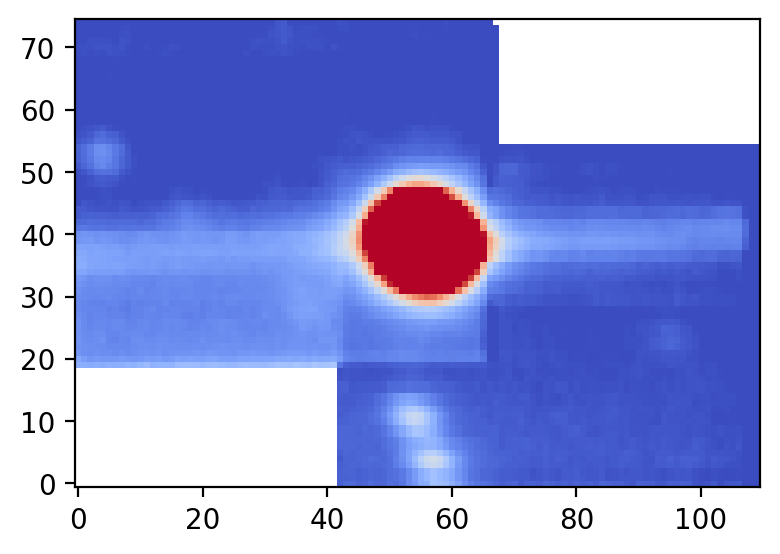

In [20]:
file_coadd = '/home/ahmed/kcwi_reduction/J045313m130555/J045313m130555_2018_02_15_Med_BL_7200s_icubes_flux.fits'

fb = fits.open(file_coadd)[0]
dfb = fb.data
hdrb = fb.header
wcsb = WCS(hdrb).celestial

wlfb = np.nanmedian(dfb[200:-200, :,:], axis=0)

plt.close()
fig = plt.figure(1, figsize=(4,4), dpi=200)
ax1 = fig.add_subplot(111)
ax1.imshow(wlfb, origin='lower', cmap='coolwarm', vmin=-0.001, vmax=0.003)
fig.tight_layout()
plt.show()


In [1]:
!pwd

/home/ahmed/kcwi_reduction/redux
